In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.sparse.linalg import eigsh
from tqdm.notebook import tqdm
import h5py

from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d

import random
from sympy import Matrix
import cvxpy as cp

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],   # default LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 15, 
})


In [22]:
with h5py.File("infidelities.hdf5", "r") as infidelity_file:
    infidelities = infidelity_file["infidelities"][...]
    trotter_steps = infidelity_file["trotter_steps"][...]
    time_steps = infidelity_file["time_steps"][...]

In [23]:
infidelities.shape

(10, 5, 20)

In [24]:
trotter_step_count = len(trotter_steps)
time_step_count = len(time_steps)

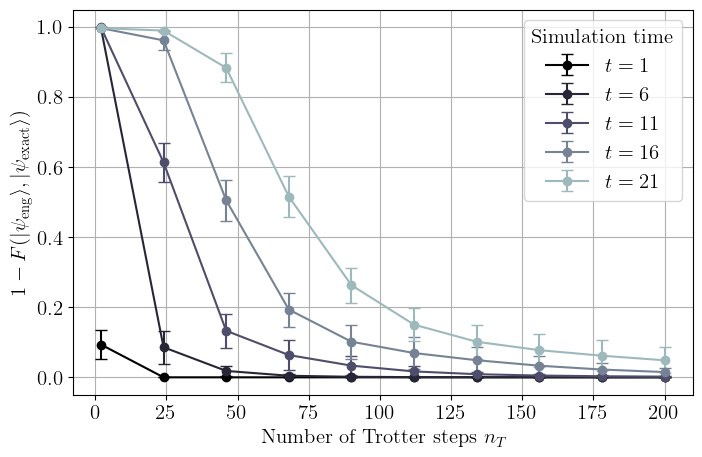

In [28]:
mean_infidelities = np.zeros((trotter_step_count,time_step_count))
sem_infidelities = np.zeros((trotter_step_count,time_step_count))
shots = 20

for j in range(time_step_count):
    for k in range (trotter_step_count):
        mean_infidelities[k][j] = np.array(infidelities[k][j]).mean()
        sem_infidelities[k][j] = np.array(infidelities[k][j]).std(ddof = 1)/np.sqrt(shots)
        
plt.figure(figsize=(8,5))


cmap = plt.cm.bone# good perceptually uniform choice
colors = cmap(np.linspace(0, 0.7, time_step_count))

for j in range(time_step_count):
    plt.errorbar(trotter_steps,mean_infidelities[:,j],yerr=sem_infidelities[:,j],fmt='o-', color = colors[j],capsize=4,label=fr"$t={int(np.round(time_steps[j],1))}$")

x = trotter_steps[0]

# plt.axvline(x=x, linestyle='--', color='black')
# # get y-axis limits
# ymin, ymax = plt.ylim()

# # place label near the x-axis
# plt.text(x, ymin-0.03, fr"$2$",
#          ha='center', va='top')

plt.xlabel(r"Number of Trotter steps $n_T$")
plt.ylabel(r"$1-F(|\psi_\mathrm{eng}\rangle,|\psi_\mathrm{exact}\rangle)$")
plt.legend(title = 'Simulation time')
plt.grid()
plt.savefig("infidelity_FHM.pdf",bbox_inches = 'tight', dpi =300, format ='pdf')